# Análisis de Rendimiento del Modelo de Reconocimiento de Actividades

Este notebook tiene como objetivo analizar los resultados de las pruebas en tiempo real de nuestro modelo de clasificación de actividades humanas. Utilizaremos el archivo de Excel donde se documentaron las predicciones del modelo frente a las actividades reales para generar:

1.  Una **Matriz de Confusión** para visualizar los aciertos y errores.
2.  Un **Reporte de Métricas Clave** (Precisión, Recall, F1-Score) para evaluar el rendimiento por cada actividad.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay



cargar el archivo

In [4]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print(f"Archivo '{file_name}' cargado exitosamente.")
df.head()

Saving pruebas.xlsx to pruebas (2).xlsx
Archivo 'pruebas (2).xlsx' cargado exitosamente.


,nombre video,timestamp inicio,timestamp final,actividad real,prediccion modelo,resultado,observaciones
0,prueba1,0:06,0:09,standing_still,standing_still,coincide,NaN
1,prueba1,0:10,0:13,sitting_down,sitting_down,coincide,en el medio de la prediccion el modelo arrojó ...
2,prueba1,0:14,0:20,sitting_still,standing_still,no coincide,NaN
3,prueba1,0:21,0:23,standing_up,standing_up,coincide,en el medio de la prediccion el modelo arrojó ...
4,prueba1,0:24,0:29,walking_towards_camera,standing_still,no coincide,el modelo no reconoce la actividad


limpieza, en caso de necesitar

In [5]:
# Renombrar columnas para que no tengan espacios y sean más fáciles de usar
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# Eliminar filas donde la actividad real o la predicción estén vacías
df.dropna(subset=['actividad_real', 'prediccion_modelo'], inplace=True)

# Asegurarse de que las etiquetas sean de tipo string y sin espacios extra
df['actividad_real'] = df['actividad_real'].astype(str).str.strip()
df['prediccion_modelo'] = df['prediccion_modelo'].astype(str).str.strip()

# Asignar los datos a las variables estándar para métricas (y_true, y_pred)
y_true = df['actividad_real']
y_pred = df['prediccion_modelo']

print("Datos preparados para el análisis.")
print(f"Total de eventos a analizar: {len(df)}")

Datos preparados para el análisis.
Total de eventos a analizar: 55


## Paso 3: Análisis Visual - Matriz de Confusión

La matriz de confusión es la mejor herramienta para entender visualmente el rendimiento del modelo. Nos muestra:
*   **La diagonal principal (de arriba-izquierda a abajo-derecha):** Muestra todas las predicciones correctas. Cuanto más altos sean estos números, mejor.
*   **Fuera de la diagonal:** Muestra los errores. Cada celda nos dice qué actividad real fue confundida con qué otra actividad predicha.

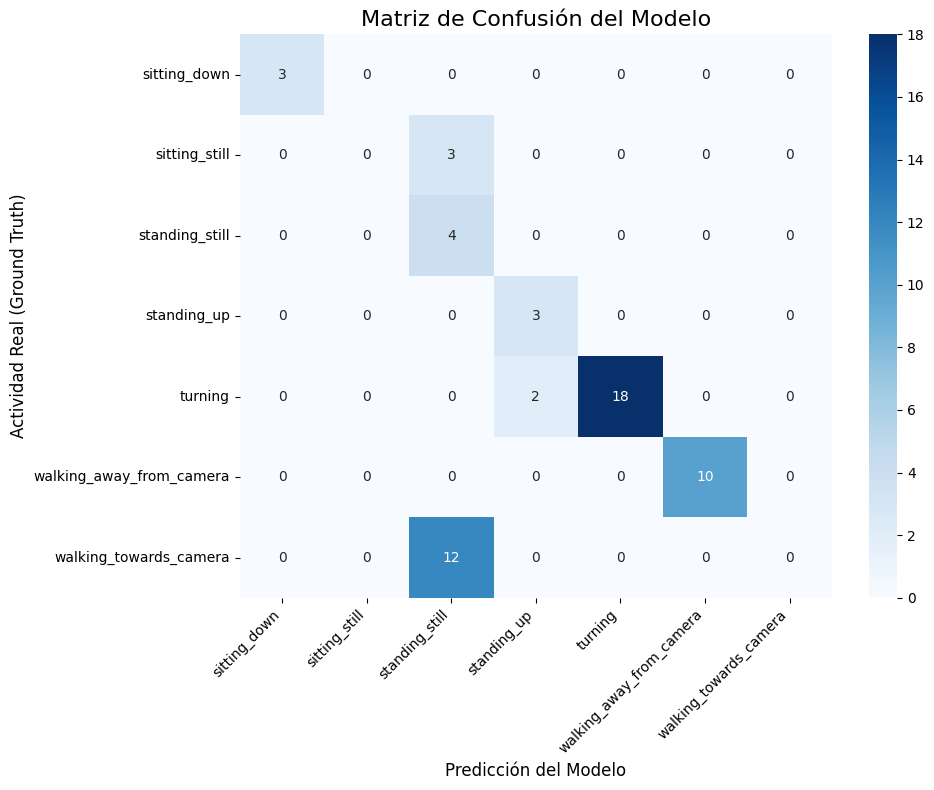

In [7]:
# Obtener la lista de todas las actividades posibles en orden alfabético para las etiquetas
class_labels = sorted(y_true.unique())

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=class_labels)

# Visualizar la matriz de confusión usando un mapa de calor para que sea más fácil de leer
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('Matriz de Confusión del Modelo', fontsize=16)
plt.ylabel('Actividad Real (Ground Truth)', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Reporte de Métricas Clave

Ahora, vamos a cuantificar el rendimiento con las métricas estándar de la industria.

In [8]:
# Generar y mostrar el reporte de clasificación
report = classification_report(y_true, y_pred, labels=class_labels, zero_division=0)

print("="*60)
print("       Reporte de Métricas de Clasificación")
print("="*60)
print(report)
print("="*60)

       Reporte de Métricas de Clasificación
                          precision    recall  f1-score   support

            sitting_down       1.00      1.00      1.00         3
           sitting_still       0.00      0.00      0.00         3
          standing_still       0.21      1.00      0.35         4
             standing_up       0.60      1.00      0.75         3
                 turning       1.00      0.90      0.95        20
walking_away_from_camera       1.00      1.00      1.00        10
  walking_towards_camera       0.00      0.00      0.00        12

                accuracy                           0.69        55
               macro avg       0.54      0.70      0.58        55
            weighted avg       0.65      0.69      0.65        55



## Interpretación de Resultados

Con la matriz de confusión y el reporte de métricas, vamos a sacar conclusiones:




### **Análisis y Conclusiones de los Resultados**

#### **A. Resumen General del Rendimiento**

El modelo alcanzó una **precisión general (accuracy) del 69%**, lo que indica un rendimiento moderado. Sin embargo, esta métrica general oculta una realidad muy polarizada: el modelo demuestra ser **extremadamente bueno para identificar ciertas actividades, mientras que es completamente incapaz de reconocer otras**.

El análisis detallado revela que el rendimiento varía drásticamente entre las diferentes clases, sugiriendo que el modelo ha aprendido patrones muy específicos para algunas acciones, pero ha fallado en generalizar para otras.

#### **B. Fortalezas del Modelo**

El modelo ha demostrado un rendimiento casi perfecto en la identificación de actividades con patrones de movimiento claros y distintivos:

1.  **`sitting_down` y `walking_away_from_camera` (F1-Score: 1.00):** El modelo identificó estas dos actividades con un 100% de precisión y recall. Esto sugiere que la acción de sentarse y el patrón de una persona que se aleja (reduciendo su tamaño en el cuadro) son características muy fuertes y únicas que el modelo aprendió a la perfección.

2.  **`turning` (F1-Score: 0.95):** Con un rendimiento casi perfecto, el modelo es muy robusto para detectar giros.

3.  **`standing_up` (F1-Score: 0.75):** El modelo también es bastante competente para detectar la acción de levantarse, con un recall perfecto (1.00), aunque con una precisión más baja (0.60). Esto significa que nunca falló en detectar cuando alguien se levantaba, pero a veces predijo "levantarse" incorrectamente.

#### **C. Debilidades Críticas y Áreas de Mejora**

El modelo presenta fallos críticos en la distinción de estados estáticos o en movimientos que son visualmente ambiguos.

1.  **Fallo Total en `sitting_still` y `walking_towards_camera` (F1-Score: 0.00):**
    *   El modelo **nunca** fue capaz de identificar correctamente cuando una persona estaba sentada quieta o caminando hacia la cámara.
    *   Un F1-Score de 0.00 significa que tanto la precisión como el recall fueron cero. El modelo es, en la práctica, "ciego" a estas dos actividades.
    *   **Hipótesis:** Es probable que el modelo confunda `sitting_still` con `standing_still`. Para `walking_towards_camera`, el cambio de escala (la persona se hace más grande) puede ser una característica que el modelo no aprendió a interpretar, a diferencia del movimiento de alejarse.

2.  **El Problema de `standing_still`**
    *   Esta es la clase más interesante y problemática. Tiene un **recall perfecto (1.00)** pero una **precisión desastrosa (0.21)**.
    *   **¿Qué significa esto?**
        *   **Recall de 1.00:** Si una persona *realmente* estaba parada, el modelo siempre lo detectó.
        *   **Precisión de 0.21:** Sin embargo, cuando el modelo *predijo* `standing_still`, solo acertó el 21% de las veces. Esto significa que **el modelo está usando `standing_still` como una categoría "comodín" o "por defecto"**.
    *   **Conclusión Clave:** Cuando el modelo no sabe si alguien está `sitting_still` o `walking_towards_camera`, su respuesta predeterminada es etiquetarlo como `standing_still`. Esto explica por qué el recall es alto (nunca falla en encontrarlo) pero la precisión es baja (lo usa incorrectamente la mayor parte del tiempo).


### **D. Análisis de la Causa Raíz: Ambigüedad de Características y Sensibilidad del Modelo**

Si bien el conjunto de entrenamiento contenía una cantidad adecuada de ejemplos para todas las clases, el fallo total del modelo en `sitting_still` y `walking_towards_camera` sugiere que el problema no es la falta de datos, sino la **calidad o la naturaleza de las características extraídas**.

1.  **Ambigüedad Postural entre Estados Estáticos (`sitting_still` vs. `standing_still`):**
    *   El modelo parece incapaz de diferenciar entre "estar sentado quieto" y "estar de pie quieto". Ambas actividades se caracterizan por una velocidad de articulaciones cercana a cero.
    *   **Hipótesis Principal:** Es muy probable que las características que hemos diseñado (como ángulos de articulaciones y longitud normalizada de pierna) sean **casi idénticas** en ambas posturas desde la perspectiva de la cámara. Si la parte superior del cuerpo está en una posición similar y no hay movimiento, el modelo no tiene suficiente información para distinguirlas. El fallo no está en que no haya visto suficientes ejemplos, sino en que los ejemplos de ambas clases son indistinguibles con las características actuales.

2.  **Fallo en la Detección de Movimiento Frontal (`walking_towards_camera`):**
    *   El modelo identifica perfectamente el alejamiento (`walking_away`) pero no el acercamiento. El alejamiento implica una reducción clara en el tamaño aparente del esqueleto en el cuadro. El acercamiento, por el contrario, implica un aumento.
    *   **Hipótesis Principal:** El modelo podría ser **excesivamente sensible a las condiciones iniciales del movimiento**. Es posible que el patrón de "caminar hacia la cámara" se confunda con `standing_still` en los primeros instantes, antes de que el cambio de escala sea lo suficientemente pronunciado. Si el modelo clasifica erróneamente los primeros fotogramas de la secuencia, la ventana deslizante podría "contaminarse" con la predicción incorrecta, impidiendo que se recupere.

3.  **`standing_still` como "Clase de Falla Segura":**
    *   La combinación de un recall perfecto y una precisión muy baja para `standing_still` confirma que el modelo la utiliza como una categoría "refugio" o "por defecto". Cuando se enfrenta a la ambigüedad de `sitting_still` o a la incertidumbre de `walking_towards_camera`, el modelo opta por la predicción más segura y genérica que conoce: `standing_still`.

### **E. Plan de Acción y Próximos Pasos**


1.  **Ingeniería de Características Avanzada:**
    *   **Para diferenciar `sitting_still` de `standing_still`:** La solución más prometedora es crear una nueva característica que capture la **altura vertical absoluta o relativa del torso**. Por ejemplo, se podría calcular la coordenada 'y' del punto medio de las caderas (`hip_center`) y normalizarla con respecto a la altura total del cuadro de video. Esta característica tendría un valor significativamente diferente entre estar sentado y estar de pie, rompiendo la ambigüedad.
    *   **Para mejorar `walking_towards_camera`:** Introducir características que midan explícitamente el **cambio de escala del esqueleto**. Se podría calcular el "área" del bounding box del esqueleto en cada fotograma y luego calcular su derivada o cambio a lo largo del tiempo dentro de la ventana deslizante. Un cambio positivo y sostenido sería un fuerte indicador de que alguien se está acercando.

2.  **Ajuste del Post-Procesamiento (Suavizado Temporal):**
    *   El mecanismo de suavizado temporal (voto mayoritario en la ventana de predicción) podría estar jugando en contra. Si el modelo se equivoca al inicio de una actividad, el suavizado puede hacer que el error persista. Se podría experimentar con **umbrales de voto más bajos o ventanas de tiempo más cortas** para permitir que el modelo cambie de opinión más rápidamente cuando detecta un nuevo patrón de movimiento.

3.  **Análisis de Errores a Nivel de Fotograma:**
    *   En lugar de solo mirar el resultado final, sería útil visualizar las predicciones del modelo *antes* del suavizado temporal. Esto podría revelar si el modelo detecta `walking_towards_camera` correctamente por unos pocos fotogramas antes de ser "silenciado" por la predicción mayoritaria de `standing_still`. Este análisis más profundo puede guiar mejor los ajustes en el modelo o en la ingeniería de características.